#IMPORT RELEVANT LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#DATA LOADING & Initial Exploration

In this section, we load and inspect the datasets used for the analysis.

The Kaggle repository contains two datasets related to unemployment in India. Initially, it was unclear whether to merge both datasets or analyze them separately. However, due to differences in structure, column composition, and data coverage, both datasets are analyzed independently to preserve data integrity and ensure meaningful insights.

- The first dataset (`df_main`) contains unemployment statistics along with geographic coordinates (latitude and longitude), making it suitable for geospatial analysis.
- The second dataset (`df_geo`) contains additional observations and includes an `Area` column (Urban/Rural), making it more suitable for trend and structural analysis.

This approach allows us to leverage the strengths of each dataset without introducing inconsistencies through forced merging.

In [3]:
df_main  = pd.read_csv('/content/drive/MyDrive/unemployement_Analysis/Unemployment_Rate_upto_11_2020.csv')

In [4]:
df_geo = pd.read_csv("/content/drive/MyDrive/unemployement_Analysis/Unemployment in India.csv")

In [5]:
df_main.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


### Preview of Dataset 1 (`df_main`)

The first few rows of the dataset show:

- Each row represents unemployment statistics for a specific region and date.
- The `Estimated Unemployment Rate (%)` varies across months, with a notable spike observed in April 2020 (e.g., Andhra Pradesh shows an increase from ~5% in earlier months to over 20% in April 2020).
- The `Estimated Employed` column shows a sharp decline during the same period, indicating job losses.
- The `Estimated Labour Participation Rate (%)` also drops during this time, suggesting reduced workforce engagement.
- The presence of `longitude` and `latitude` confirms that this dataset can support geospatial analysis.
- The `Region.1` column appears to represent broader zones (e.g., South), which may be useful for grouped analysis.

This initial preview already hints at the economic disruption caused during early 2020.

In [6]:
df_geo.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


### Preview of Dataset 2 (`df_geo`)

The first few rows reveal:

- The dataset includes similar unemployment indicators as Dataset 1.
- The `Area` column categorizes data into Rural and Urban regions, enabling comparative analysis.
- The unemployment rates in 2019 (e.g., ~3–5%) appear relatively stable compared to the spikes observed in 2020 in Dataset 1.
- The `Estimated Employed` values are relatively high and stable in this early period, suggesting a more stable labor market before COVID-19.
- The `Frequency` column is labeled as "Monthly", indicating consistent time intervals.

This dataset provides a broader temporal view and is useful for understanding baseline trends before the pandemic.

In [7]:
df_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    267 non-null    object 
 1    Date                                     267 non-null    object 
 2    Frequency                                267 non-null    object 
 3    Estimated Unemployment Rate (%)          267 non-null    float64
 4    Estimated Employed                       267 non-null    int64  
 5    Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region.1                                  267 non-null    object 
 7   longitude                                 267 non-null    float64
 8   latitude                                  267 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 18.9+ KB


### Structure of Dataset 1 (`df_main`)

The dataset contains **267 entries and 9 columns**.

Key observations:
- There are **no missing values**, indicating a clean dataset.
- Data types include:
  - Numerical features: unemployment rate, employed population, labour participation rate, latitude, longitude
  - Categorical features: region, frequency, and zone (`Region.1`)
- The `Date` column is currently stored as an object and will need to be converted to a datetime format for time-series analysis.

Overall, this dataset is well-structured and ready for analysis after minor preprocessing.

In [8]:
df_geo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


### Structure of Dataset 2 (`df_geo`)

The dataset contains **768 entries**, but only **740 non-null values** across columns, indicating the presence of missing data.

Key observations:
- Missing values are present in all columns, which will require handling during data cleaning.
- Data types include:
  - Numerical features: unemployment rate, employment, labour participation rate
  - Categorical features: region, frequency, and area (Urban/Rural)
- The `Date` column is also stored as an object and will need conversion to datetime format.

Compared to Dataset 1, this dataset is larger but requires additional preprocessing due to missing values.

#DATA CLEANING & PRE-PROCESSING

In this section, we prepare the datasets for analysis by ensuring consistency, handling missing values, correcting data types, and standardizing column names.

Proper data cleaning is essential to ensure that subsequent analysis is accurate, reliable, and meaningful.

##Column Name Standardization

In [9]:
df_main.columns = df_main.columns.str.strip()
df_geo.columns = df_geo.columns.str.strip()

The column names in both datasets were cleaned by removing leading and trailing spaces.

This step is important because inconsistent column names (e.g., extra spaces) can lead to errors during data manipulation and analysis. Standardizing column names ensures consistency and prevents unexpected bugs when referencing columns.

## Dealing With Missing Values

In [10]:
df_geo.isnull().sum()

,0
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


A check for missing values reveals that Dataset 2 (`df_geo`) contains missing entries across all columns, totaling **28 rows**.

This indicates that some observations are incomplete and may affect the reliability of the analysis if not handled properly.

In [11]:
df_geo.dropna(inplace=True)

All rows containing missing values were removed from the dataset.

This decision was made because:
- The missing values were spread across entire rows rather than isolated columns.
- There was no clear or reliable basis for imputing these values.
- The number of missing rows (28 out of 768) is relatively small (~3.6%), meaning their removal does not significantly impact the overall dataset.

Removing these rows ensures that the analysis is based on complete and reliable data.

In [12]:
df_geo.isnull().sum()

,0
Region,0
Date,0
Frequency,0
Estimated Unemployment Rate (%),0
Estimated Employed,0
Estimated Labour Participation Rate (%),0
Area,0


After dropping missing values, a recheck confirms that there are now **no missing entries** in the dataset.

This ensures that the dataset is clean and ready for further analysis.

## Distribution of Area (Urban vs Rural)

In [13]:
df_geo['Area'].value_counts()

,count
Area,
Urban,381
Rural,359


The dataset contains in Dataset 2:
- **381 Urban observations**
- **359 Rural observations**

This indicates a relatively balanced distribution between Urban and Rural areas, ensuring that comparisons between these categories are not biased due to data imbalance.

## Summary Statistics

In [14]:
df_main.describe(include='all')

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
count,267,267,267,267.000000,2.670000e+02,267.000000,267,267.000000,267.000000
unique,27,10,1,NaN,NaN,NaN,5,NaN,NaN
top,Andhra Pradesh,31-05-2020,M,NaN,NaN,NaN,North,NaN,NaN
freq,10,27,267,NaN,NaN,NaN,79,NaN,NaN
mean,NaN,NaN,NaN,12.236929,1.396211e+07,41.681573,NaN,22.826048,80.532425
std,NaN,NaN,NaN,10.803283,1.336632e+07,7.845419,NaN,6.270731,5.831738
min,NaN,NaN,NaN,0.500000,1.175420e+05,16.770000,NaN,10.850500,71.192400
25%,NaN,NaN,NaN,4.845000,2.838930e+06,37.265000,NaN,18.112400,76.085600
50%,NaN,NaN,NaN,9.650000,9.732417e+06,40.390000,NaN,23.610200,79.019300
75%,NaN,NaN,NaN,16.755000,2.187869e+07,44.055000,NaN,27.278400,85.279900


Key observations from the dataset:

- The average unemployment rate is approximately **12.24%**, with a wide range from **0.5% to 75.85%**, indicating significant variability across regions and time.
- The standard deviation of **10.80%** suggests high dispersion in unemployment rates.
- The median unemployment rate (**9.65%**) is lower than the mean, indicating a slight right skew, possibly due to extreme values during economic shocks.
- The average estimated employed population is approximately **13.96 million**, with large variation across regions.
- The labour participation rate averages around **41.68%**, reflecting moderate workforce engagement.

Additionally:
- The dataset contains **27 unique regions (states)**.
- The `Frequency` column contains only one value ("M"), indicating monthly data.

In [15]:
df_geo.describe(include='all')

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
count,740,740,740,740.000000,7.400000e+02,740.000000,740
unique,28,14,2,NaN,NaN,NaN,2
top,Andhra Pradesh,31-10-2019,Monthly,NaN,NaN,NaN,Urban
freq,28,55,381,NaN,NaN,NaN,381
mean,NaN,NaN,NaN,11.787946,7.204460e+06,42.630122,NaN
std,NaN,NaN,NaN,10.721298,8.087988e+06,8.111094,NaN
min,NaN,NaN,NaN,0.000000,4.942000e+04,13.330000,NaN
25%,NaN,NaN,NaN,4.657500,1.190404e+06,38.062500,NaN
50%,NaN,NaN,NaN,8.350000,4.744178e+06,41.160000,NaN
75%,NaN,NaN,NaN,15.887500,1.127549e+07,45.505000,NaN


Key observations for Dataset 2:

- The average unemployment rate is approximately **11.79%**, similar to Dataset 1, suggesting consistency between datasets.
- The unemployment rate ranges from **0% to 76.74%**, again indicating high variability.
- The average labour participation rate is **42.63%**, slightly higher than Dataset 1.
- The dataset includes **28 unique states** (column called region now, but would be renamed soon), suggesting slightly broader coverage.

Additional observations:
- The `Area` column confirms two categories: Urban and Rural.
- The dataset contains more observations than Dataset 1, making it useful for broader trend analysis.

## Inspecting Date Format

In [16]:
df_main['Date'].unique()

array([' 31-01-2020', ' 29-02-2020', ' 31-03-2020', ' 30-04-2020',
       ' 31-05-2020', ' 30-06-2020', ' 31-07-2020', ' 31-08-2020',
       ' 30-09-2020', ' 31-10-2020'], dtype=object)

In [17]:
df_geo['Date'].unique()

array([' 31-05-2019', ' 30-06-2019', ' 31-07-2019', ' 31-08-2019',
       ' 30-09-2019', ' 31-10-2019', ' 30-11-2019', ' 31-12-2019',
       ' 31-01-2020', ' 29-02-2020', ' 31-03-2020', ' 30-04-2020',
       ' 31-05-2020', ' 30-06-2020'], dtype=object)

The `Date` column contains values in string format with leading spaces and follows a **day-month-year format (DD-MM-YYYY)**.

This format must be converted into a proper datetime datatype to enable time-series analysis.

##Convert Date to Datetime Format


In [53]:
df_main['Date'] = pd.to_datetime(df_main['Date'], dayfirst=True)
df_geo[' Date'] = pd.to_datetime(df_geo['Date'], dayfirst=True)

The `Date` column in both datasets was converted from string format to datetime format.

The parameter `dayfirst=True` was used because the dates are in **DD-MM-YYYY format**, ensuring correct parsing and avoiding misinterpretation of day and month values.

This step enables proper time-based analysis such as trend visualization and time-series comparisons.

##Frequency Check

In [19]:
df_main['Frequency'].value_counts()

,count
Frequency,
M,267


In [20]:
df_geo['Frequency'].value_counts()

,count
Frequency,
Monthly,381
Monthly,359


- In Dataset 1, all entries have a frequency labeled as **"M"**, indicating monthly data.
- In Dataset 2, the frequency is labeled as **"Monthly"**, though duplicated entries suggest minor inconsistencies in formatting.

Despite the difference in representation ("M" vs "Monthly"), both datasets operate on a monthly frequency, ensuring consistency for time-based analysis. There wouldn't be use  the frequency column because we just have a single category of entry.

In [21]:
df_main['Region'].nunique()

27

The dataset contains **27 unique regions**, which correspond to states in India.

Based on external reference, India has 28 states, indicating that one state (Arunachal Pradesh) is not present in this dataset.

Since the values represent states rather than broader regions, it is more accurate to rename this column to `State` for clarity and correctness.

In [22]:
df_main.rename(columns={'Region':'State'}, inplace=True)

In [23]:
df_main.rename(columns={'Region.1':'Region'}, inplace=True)

- The `Region` column was renamed to `State` to reflect its actual meaning.
- The `Region.1` column was renamed to `Region`, as it represents broader geographic zones (e.g., North, South).

To improve clarity and ensure that column names accurately describe the data they contain.

In [24]:
df_geo.rename(columns={'Region':'State'}, inplace=True)

Also the `Region` column in Dataset 2 was also renamed to `State` to maintain consistency across both datasets.

#EXPLORATORY DATA ANALYSIS

In this section, we explore the datasets to uncover patterns, trends, and relationships in unemployment across time, regions, and economic indicators.

The analysis is divided into two parts:
- Dataset A (`df_main`) – focused on regional and geospatial insights
- Dataset B (`df_geo`) – focused on structural insights such as Urban vs Rural dynamics

Each analysis is guided by specific hypotheses to ensure a structured and meaningful exploration.

##Dataset A- `df_main`

### A. Overall Unemployment Trend

**Hypothesis:**  
How has unemployment changed over time in Dataset A?

To answer this, we aggregate the unemployment rate by date and visualize the trend over time.

<Axes: xlabel='Date'>

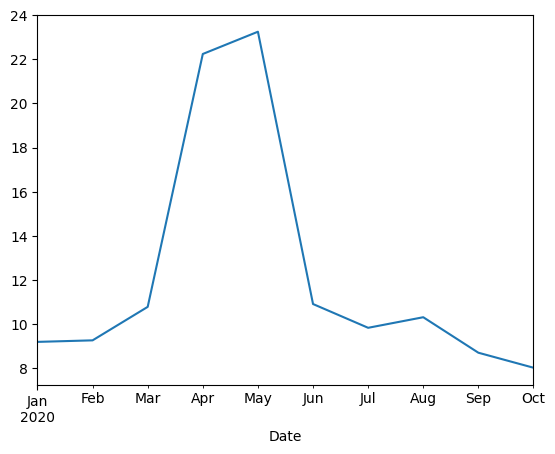

In [54]:
df_main.groupby('Date')['Estimated Unemployment Rate (%)'].mean().plot()

**Explanation:**

This plot shows the average unemployment rate across all states over time.

From the trend, unemployment appears relatively stable before early 2020, with moderate fluctuations. However, there is a **sharp spike around March–April 2020**, where unemployment increases significantly.

This sudden rise corresponds to the onset of COVID-19 restrictions, which disrupted economic activities, reduced business operations, and led to widespread job losses.

After this peak, the unemployment rate increased again in **May,2020** and  begins to decline drastically in **June, 2020**, suggesting recovery as restrictions eased.

**Key Insight:**  
COVID-19 had an immediate and severe impact on unemployment, causing a sharp but temporary surge.

###B. State Analysis

In [26]:
df_main.groupby('State')['Estimated Unemployment Rate (%)'].mean().sort_values()

,Estimated Unemployment Rate (%)
State,
Meghalaya,3.866000
Assam,4.856000
Gujarat,6.376000
Odisha,6.462000
Telangana,6.833000
Madhya Pradesh,6.854000
Karnataka,7.668000
Chhattisgarh,7.819000
Maharashtra,7.979000


**Explanation:**

Lowest unemployment states:
- Meghalaya (**4.80%**)
- Odisha (**5.66%**)

Highest unemployment states:
- Tripura (**28.35%**)
- Haryana (**26.28%**)
- Jharkhand (**20.59%**)

The pattern is consistent with Dataset A, reinforcing reliability.

**Key Insight:**  
State-level disparities persist across datasets, confirming structural differences in regional economies.

###C. Regional Analysis

In [27]:
df_main.groupby('Region')['Estimated Unemployment Rate (%)'].mean()

,Estimated Unemployment Rate (%)
Region,
East,13.916000
North,15.889620
Northeast,10.950263
South,10.454667
West,8.239000


By just calculating the Average unemployment rate by region, the **North seems to have a region records with  highest unemployment rate**, suggesting stronger economic disruption or structural challenges.

The **West region has the lowest unemployment**, indicating relatively stronger economic stability.

However for a more thorough analysis we would have to look at how the unemployment rate looks like in the pre-Covid19 era to see the true impact of it

### D. COVID-19 Impact On Dataset A

`Hypothesis:`

What is the impact of COVID-19 on unemployment across regions?

In [28]:
before = df_main[df_main['Date'] < '2020-03']
after = df_main[df_main['Date'] >= '2020-03']

To investigate this, the dataset is divided into two periods:
- Pre-COVID (before March 2020)
- Post-COVID (March 2020 and after)

We then compare the average unemployment rates across regions in both periods.

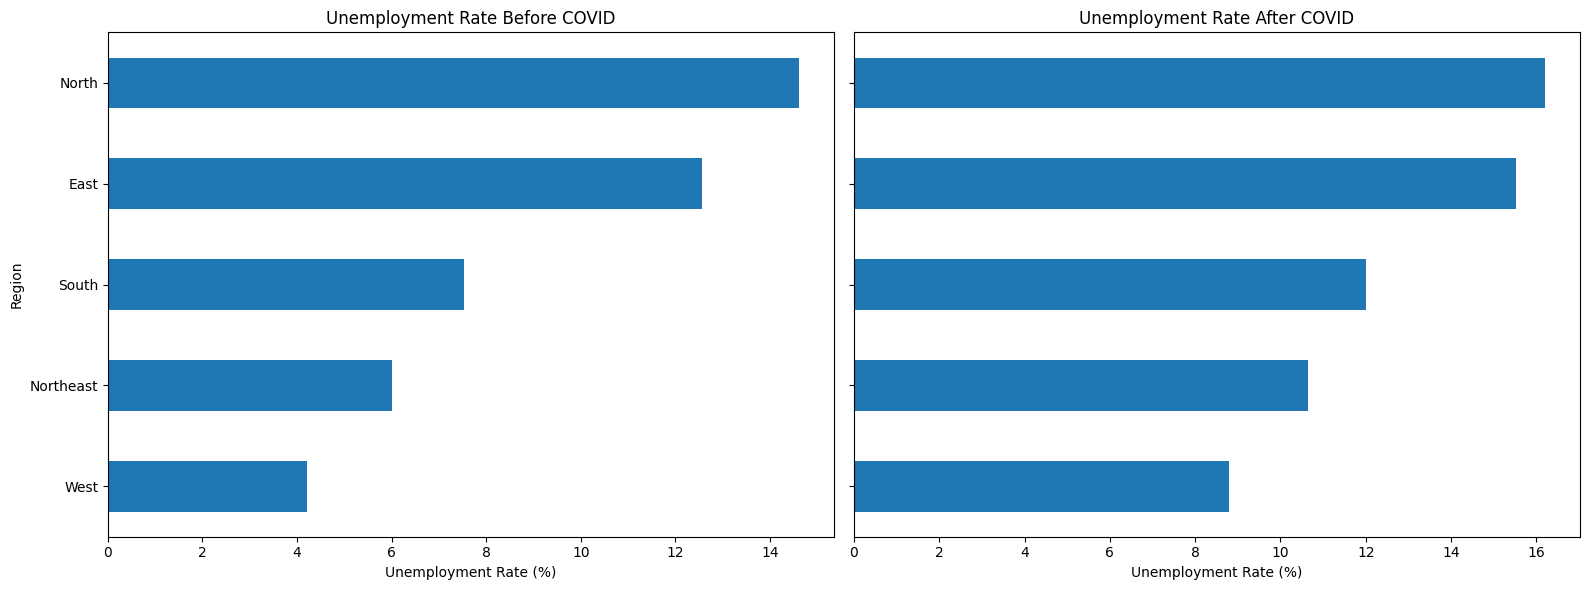

In [29]:
# Group data
before_avg = before.groupby('Region')['Estimated Unemployment Rate (%)'].mean()
after_avg = after.groupby('Region')['Estimated Unemployment Rate (%)'].mean()

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Before COVID
before_avg.sort_values().plot(kind='barh', ax=axes[0])
axes[0].set_title('Unemployment Rate Before COVID')
axes[0].set_xlabel('Unemployment Rate (%)')


# After COVID
after_avg.sort_values().plot(kind='barh', ax=axes[1])
axes[1].set_title('Unemployment Rate After COVID')
axes[1].set_xlabel('Unemployment Rate (%)')

plt.tight_layout()
plt.show()

Before COVID-19:

The North and East recorded the highest unemployment rates, indicating pre-existing structural challenges.
The West and Northeast had relatively low unemployment levels, suggesting more stable labor conditions prior to the pandemic.

After COVID-19:

All regions experienced an increase in unemployment, confirming a widespread economic shock.
However, the magnitude of change varied significantly across regions:
The Northeast and West experienced the most dramatic increases, with unemployment rates nearly doubling.
The South also saw a substantial rise, though not as extreme.
The North and East recorded smaller proportional increases, despite already having high unemployment levels.

Key Insight:

COVID-19 had a universal impact, but its severity differed depending on the region’s starting point.
Regions with initially low unemployment (West and Northeast) were more vulnerable to sudden economic shocks, experiencing the largest proportional increases.
In contrast, regions with already high unemployment (North and East) remained the most affected in absolute terms but showed less relative change.

###E. Estimated Employed

`Hypothesis`:

How does employment change with unemployment in `Dataset A`?

<Axes: xlabel='Estimated Employed', ylabel='Estimated Unemployment Rate (%)'>

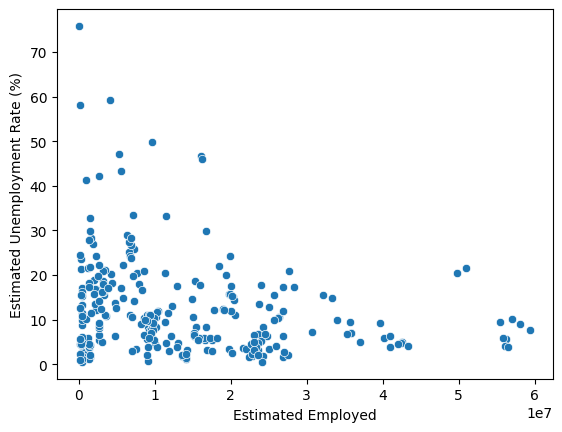

In [49]:
sns.scatterplot(
    x='Estimated Employed',
    y='Estimated Unemployment Rate (%)',
    data=df_main
)

**Explanation:**

This scatter plot shows the relationship between the number of employed individuals and the unemployment rate across states.


From the plot:

- There is a **general downward tendency**, where states with higher employment levels tend to have lower unemployment rates.
- However, the points are **widely dispersed**, indicating that the relationship is not strictly linear.
- Several states with similar employment levels show different unemployment rates, suggesting the influence of additional factors such as economic structure or population size.
- A few points appears as **outliers**, where unemployment is high despite relatively large employment figures—this could indicate large labor forces where job creation is still insufficient.

**Key Insight:**

While higher employment generally corresponds to lower unemployment, the relationship is **weak to moderate rather than strong**, indicating that employment size alone does not fully explain unemployment levels. Other structural and regional factors also play a significant role.

###F. Labour Participation Rate

`Hypothesis`:

Does higher participation mean higher unemployment for `Dataset A`?

<Axes: xlabel='Estimated Labour Participation Rate (%)', ylabel='Estimated Unemployment Rate (%)'>

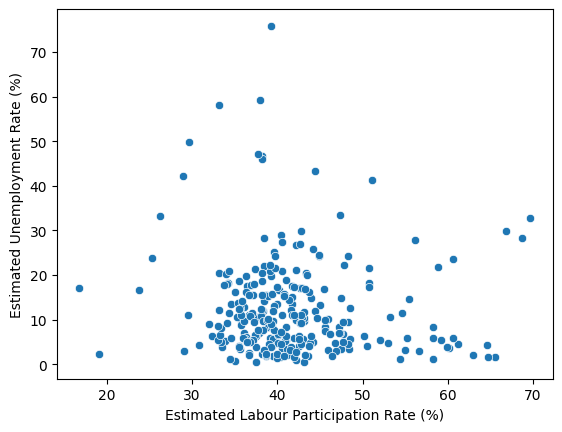

In [31]:
sns.scatterplot(
    x='Estimated Labour Participation Rate (%)',
    y='Estimated Unemployment Rate (%)',
    data=df_main
)

This scatter plot explores the relationship between **labour participation rate** and **unemployment rate**.
- Distribution of Points:
The data points are spread across the chart without forming a strong linear trend. This suggests that the relationship between participation and unemployment is complex and context-dependent.

- Patterns Observed: In some clusters, higher participation coincides with higher unemployment, which could reflect situations where more people are actively seeking work but job creation is limited.
- In other clusters, higher participation aligns with lower unemployment, possibly indicating healthier labour markets where more people are employed.
- Outliers (i.e, like unemployment near and over 70%, a very high unemployment rate despite moderate participation) highlight exceptional cases, perhaps due to economic shocks or structural issues.


###G. Correlation Matrix

<Axes: >

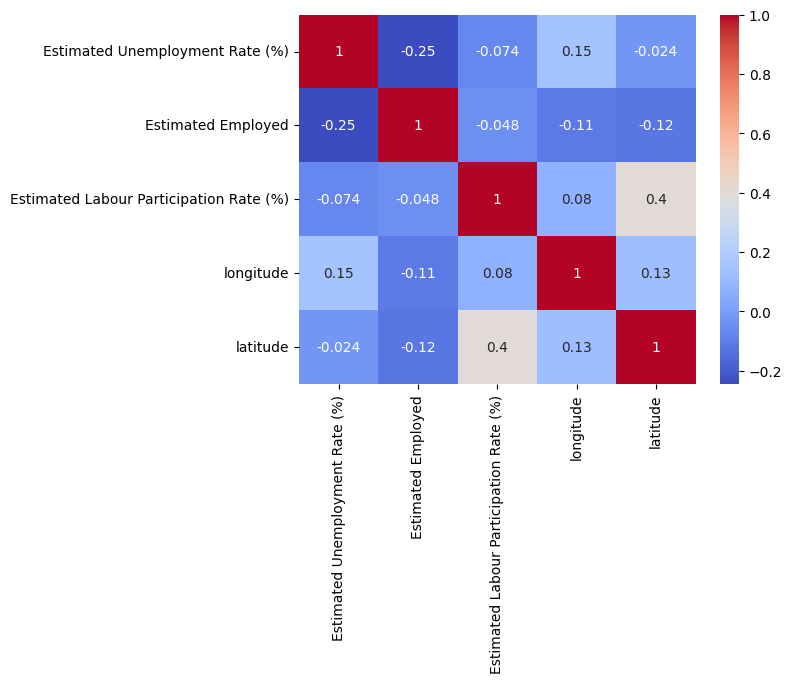

In [32]:
corr = df_main.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')

This shows use literally everything, the matrix quantifies how strongly each pair of variables is related:

- For Estimated Employed vs Unemployment Rate the correlation is -0.25, which indicates a moderate negative correlation: as employment increases, unemployment tends to decrease. This is the strongest relationship in the matrix.

- Labour Participation vs Unemployment Rate as -0.074
 which indicates a Very weak negative correlation: participation has little direct impact on unemployment, confirming the relationship is complex and indirect.

- Employment vs Labour Participation as -0.048  which indicates an essentially no correlation: being employed doesn’t strongly depend on participation rate in this dataset.

- Geographic Factors (longitude, latitude):
- Unemployment vs longitude as 0.15 (weak positive)
- Unemployment vs latitude as -0.024 (negligible)
- Labour Participation vs latitude as 0.40 (moderate positive correlation, the second strongest in the matrix)
- And  Other geographic correlations like (longitude vs latitude = 0.13) are simply just very weak.



##Dataset B - `df_geo`

###A. Overall Unemployment Trend

`Hypothesis`:

How has `unemployment` changed over `time`in Dataset B?

<Axes: xlabel=' Date'>

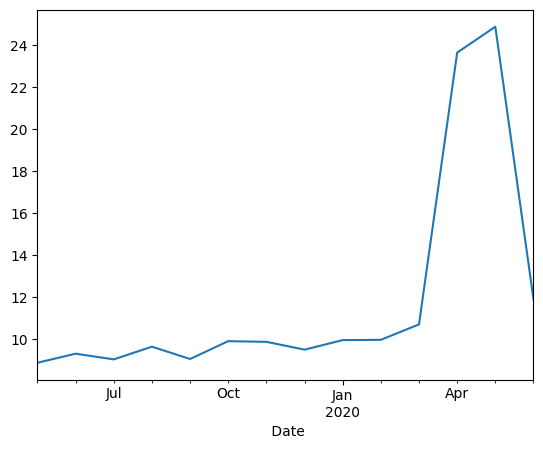

In [59]:
df_geo.groupby(' Date')['Estimated Unemployment Rate (%)'].mean().plot()

**Explanation:**

The unemployment trend in Dataset B shows a similar pattern to Dataset A.

- Stable unemployment levels throughout 2019
- A **sharp increase around early 2020**
- Followed by a gradual decline

This consistency across datasets confirms that the observed spike is not random but linked to a real-world event.

**Key Insight:**  
Both datasets validate that COVID-19 caused a significant spike in unemployment.

###B. State Analysis

In [38]:
df_geo.groupby('State')['Estimated Unemployment Rate (%)'].mean().sort_values()

,Estimated Unemployment Rate (%)
State,
Meghalaya,4.798889
Odisha,5.657857
Assam,6.428077
Uttarakhand,6.582963
Gujarat,6.663929
Karnataka,6.676071
Sikkim,7.249412
Madhya Pradesh,7.406429
Andhra Pradesh,7.477143


**Explanation:**

Lowest unemployment states:
- Meghalaya (**4.80%**)
- Odisha (**5.66%**)

Highest unemployment states:
- Tripura (**28.35%**)
- Haryana (**26.28%**)
- Jharkhand (**20.59%**)

The pattern is consistent with Dataset A, reinforcing reliability.

**Key Insight:**  
State-level disparities persist across datasets, confirming structural differences in regional economies.

###C. Urban vs Rural Analysis

In [40]:
#To confirm the unique value in state Column
df_geo.loc[df_geo['State'] == 'Andhra Pradesh', 'Area'].unique()

array(['Rural', 'Urban'], dtype=object)

In [37]:
df_geo.groupby('Area')['Estimated Unemployment Rate (%)'].mean()

,Estimated Unemployment Rate (%)
Area,
Rural,10.324791
Urban,13.166614


**Explanation:**

Unlike Dataset A, Dataset B do not have Regional feature but it has Areas and it is categorized into Urban and Rural categories. The Average unemployment rates of Urban Areas is **13.17%** and  Rural Areas is **10.32%**, therefore, Urban unemployment is clearly higher than Rural.

**Key Insight:**  
Urban areas are more vulnerable to economic shocks, while rural areas show relatively more stability.

###D. COVID-19 Impact On Dataset B

`Hypothesis:`

What is the impact COVID-19 to the Country

In [34]:
geo_before = df_geo[df_geo[' Date'] < '2020-03']
geo_after = df_geo[df_geo[' Date'] >= '2020-03']

In [35]:
geo_after

,State,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Date
10,Andhra Pradesh,31-03-2020,Monthly,4.06,11359660.0,40.66,Rural,2020-03-31
11,Andhra Pradesh,30-04-2020,Monthly,16.29,8792827.0,36.03,Rural,2020-04-30
12,Andhra Pradesh,31-05-2020,Monthly,14.46,9526902.0,38.16,Rural,2020-05-31
13,Andhra Pradesh,30-06-2020,Monthly,0.85,15572975.0,53.76,Rural,2020-06-30
23,Assam,31-03-2020,Monthly,3.77,9878742.0,47.05,Rural,2020-03-31
...,...,...,...,...,...,...,...,...
739,Uttarakhand,30-06-2020,Monthly,5.08,989470.0,35.61,Urban,2020-06-30
750,West Bengal,31-03-2020,Monthly,6.67,10806105.0,43.34,Urban,2020-03-31
751,West Bengal,30-04-2020,Monthly,15.63,9299466.0,41.20,Urban,2020-04-30
752,West Bengal,31-05-2020,Monthly,15.22,9240903.0,40.67,Urban,2020-05-31


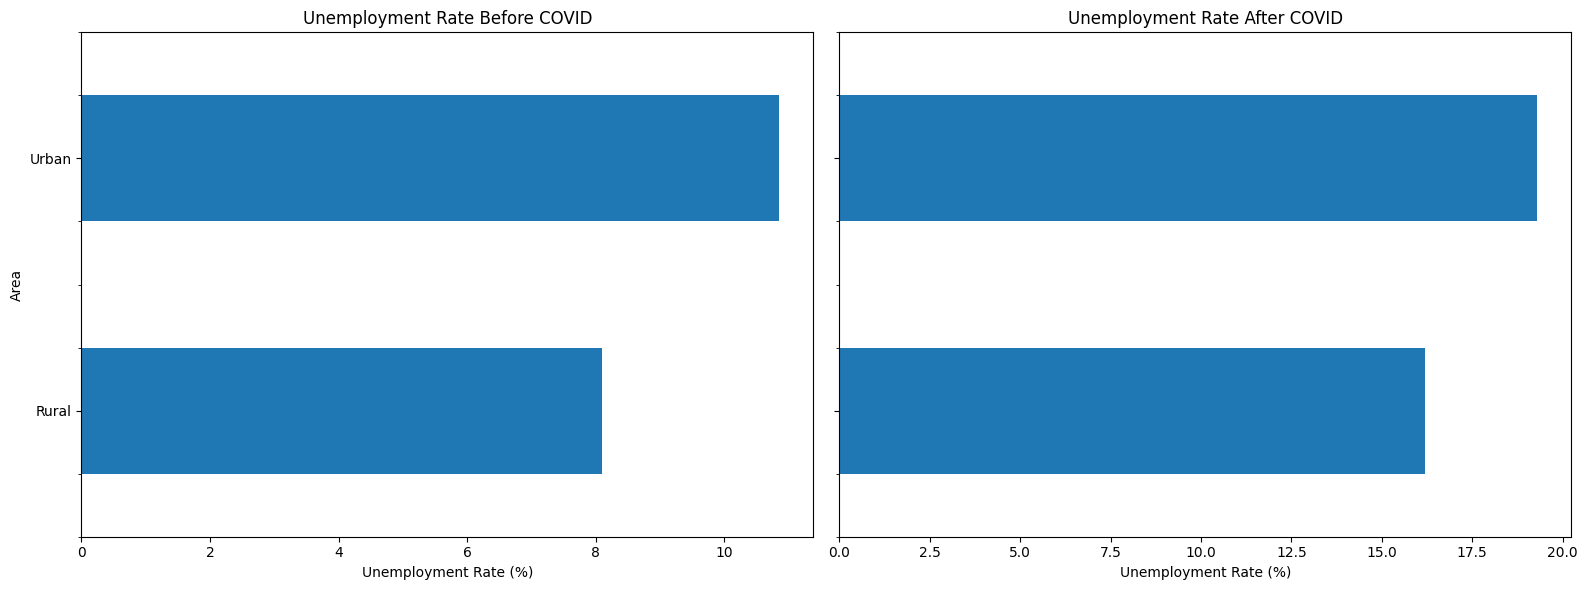

In [36]:
# Group data
geo_before_avg = geo_before.groupby('Area')['Estimated Unemployment Rate (%)'].mean()
geo_after_avg = geo_after.groupby('Area')['Estimated Unemployment Rate (%)'].mean()

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Before COVID
geo_before_avg.sort_values().plot(kind='barh', ax=axes[0])
axes[0].set_title('Unemployment Rate Before COVID')
axes[0].set_xlabel('Unemployment Rate (%)')


# After COVID
geo_after_avg.sort_values().plot(kind='barh', ax=axes[1])
axes[1].set_title('Unemployment Rate After COVID')
axes[1].set_xlabel('Unemployment Rate (%)')

plt.tight_layout()
plt.show()

**Explanation:**

This analysis compares Urban and Rural unemployment before and after COVID-19.

Before COVID:
- Both Urban and Rural unemployment were relatively low and stable

After COVID:
- Both categories experienced increases
- **Urban unemployment increased more significantly than Rural**

From the sample rows:
- Example: Andhra Pradesh Rural jumped from ~4% (March) to ~16% (April)

**Key Insight:**  
Urban areas were more affected by COVID-19, likely due to dependence on service industries and business closures.

###E. Estimated Employed

`Hypothesis:`

How does employment change with unemployment in `Dataset B`?

<Axes: xlabel='Estimated Employed', ylabel='Estimated Unemployment Rate (%)'>

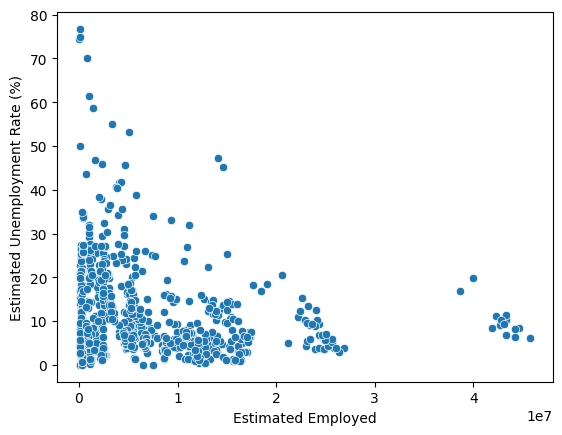

In [61]:
sns.scatterplot(
    x='Estimated Employed',
    y='Estimated Unemployment Rate (%)',
    data=df_geo
)

**Explanation:**

The scatter plot shows a **clear downward trend**, confirming a negative relationship:

- Higher employment → Lower unemployment
- Lower employment → Higher unemployment

**Key Insight:**  
Employment level is a strong inverse predictor of unemployment.

### F. Labour Participation Rate

`Hypothesis`:

Does higher participation mean higher unemployment for `Dataset B`?

<Axes: xlabel='Estimated Labour Participation Rate (%)', ylabel='Estimated Unemployment Rate (%)'>

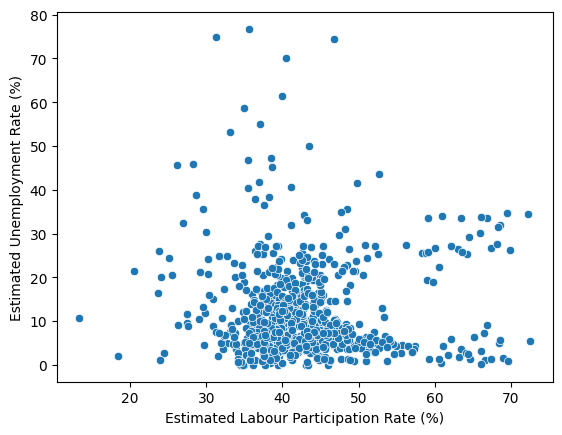

In [62]:
sns.scatterplot(
    x='Estimated Labour Participation Rate (%)',
    y='Estimated Unemployment Rate (%)',
    data=df_geo
)

**Explanation:**

The regression line is relatively flat, indicating a **weak relationship**.

There is no strong evidence that higher participation consistently increases or decreases unemployment.

**Key Insight:**  
Labour participation alone is not a reliable predictor of unemployment.

### G. Correlation Matrix

<Axes: >

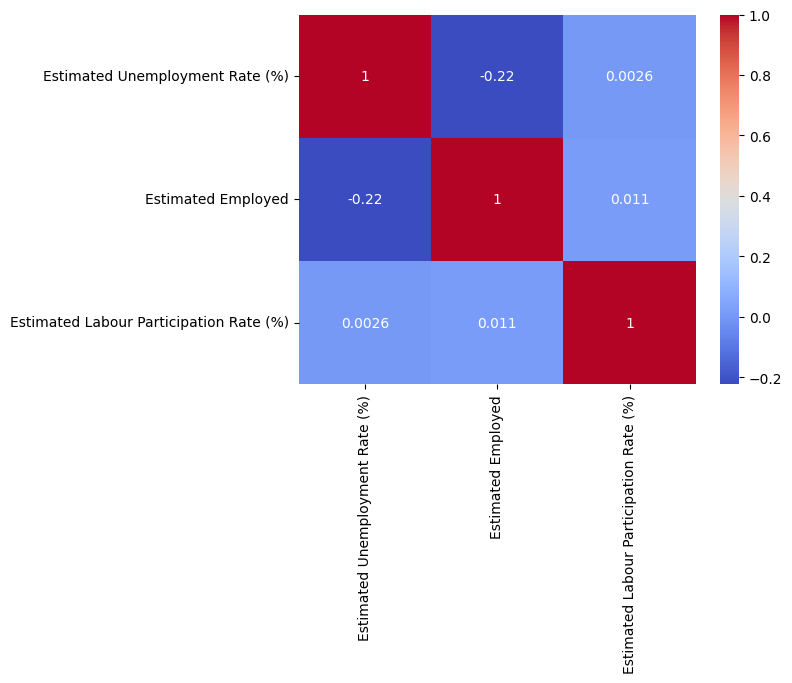

In [43]:
corr = df_geo.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')

This correlation matrix examines the relationships between employment, unemployment, and labour participation.
- Estimated Employed vs Unemployment Rate (-0.22) indicates a Moderate negative correlation: as employment increases, unemployment tends to decrease. This is the strongest relationship in Dataset B.
- Labour Participation vs Unemployment Rate (0.0026) indicates an essentially no correlation: participation does not directly explain unemployment outcomes.
- Employment vs Labour Participation (0.011) indicates a negligible correlation: employment levels are not strongly tied to participation rate in this dataset.

Key Insight:


Employment level remains the clearest predictor of unemployment (negative correlation), while labour participation shows almost no direct relationship. The consistency of these findings with Dataset A strengthens confidence in the conclusion: employment is inversely linked to unemployment, but participation is not a reliable predictor.


# COMPARATIVE INSIGHTS



To validate the consistency and robustness of the analysis, key metrics and patterns from both datasets are compared side by side.

This comparison highlights similarities, differences, and reinforces the reliability of the findings.

##Compare Overall Averages

In [44]:
main_avg = df_main['Estimated Unemployment Rate (%)'].mean()
geo_avg = df_geo['Estimated Unemployment Rate (%)'].mean()

print(main_avg, geo_avg)

12.236928838951311 11.787945945945946


## Summary Comparison of Dataset A and Dataset B



| Metric / Insight | Dataset A (df_main) | Dataset B (df_geo) | Interpretation |
|-----------------|-------------------|--------------------|----------------|
| **Average Unemployment Rate** | 12.24% | 11.79% | Very close values; strong consistency between datasets |
| **Time Trend** | Sharp spike in early 2020 | Same spike observed | Confirms COVID-19 impact is real and not dataset-specific |
| **Most Affected Regions/Areas** | North & East (highest absolute levels) | Urban areas (higher overall) | Structural differences: regional vs urban exposure |
| **Biggest COVID Impact** | West & Northeast (largest relative increase) | Urban areas most affected | Economies with lower initial unemployment were more vulnerable to shocks |
| **Lowest Unemployment Areas** | Meghalaya, Assam | Meghalaya, Odisha | Consistent low-unemployment states across datasets |
| **Highest Unemployment Areas** | Haryana, Tripura | Haryana, Tripura | Strong agreement, reinforces reliability |
| **Employment vs Unemployment** | Weak–moderate negative relationship (~ -0.25) | Moderate negative (~ -0.22) | Employment is a consistent inverse predictor |
| **Participation vs Unemployment** | Very weak relationship (~ -0.07) | No relationship (~ 0.00) | Participation does not directly determine unemployment |
| **Geographic Influence** | Weak correlations | Not applicable | Geography plays a minor role compared to economic factors |
| **Data Strength** | Includes geospatial + regional grouping | Includes Urban vs Rural classification | Complementary perspectives |


### Interpretation of Comparative Analysis

The comparison shows a high level of consistency between both datasets despite their structural differences.

- The average unemployment rates differ by only **0.45 percentage points**, indicating strong alignment.
- Both datasets clearly capture the **sharp increase in unemployment during early 2020**, confirming the economic impact of COVID-19.
- State-level patterns are highly consistent, with the same states appearing in both the highest and lowest unemployment categories.
- The relationship between employment and unemployment remains consistently negative across both datasets, reinforcing its importance as a key economic indicator.
- Labour participation, on the other hand, shows little to no direct relationship with unemployment in both datasets.

Overall, Dataset A provides stronger **regional and geospatial insights**, while Dataset B offers deeper **structural insights (Urban vs Rural)**. Together, they provide a more comprehensive understanding of unemployment dynamics.

## Final Conclusion

This analysis reveals that unemployment patterns are influenced by a combination of structural, regional, and economic factors.

Key findings include:

- COVID-19 had a **significant and immediate impact**, causing a sharp rise in unemployment across all regions and areas.
- The severity of impact varied:
  - Regions with lower initial unemployment experienced the **largest relative increases**
  - Regions with already high unemployment remained the **most affected in absolute terms**
- Urban areas proved more vulnerable to economic shocks compared to rural areas.
- Employment levels show a **consistent inverse relationship** with unemployment, making it the strongest predictor across both datasets.
- Labour participation rate does not directly determine unemployment, highlighting the complexity of labor market dynamics.

By combining insights from both datasets, this analysis provides a **robust and multi-dimensional understanding** of unemployment trends.

These findings can support policymakers and analysts in designing targeted interventions, particularly in high-risk regions and urban economies.

### Limitations

- The datasets do not cover all states equally
- No sector-specific employment data is available
- External economic variables (GDP, inflation) are not included

Future analysis could incorporate these factors for deeper insights.